# Chapter 1
## oreilly01の復習

### Layer Impelementation

In [2]:
import numpy as np
import random

class MatMul:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.x = None

    def forward(self, x):
        W, = self.params
        out = np.dot(x, W)
        self.x = x
        return out

    def backward(self, dout):   
        W, = self.params
        dx = np.dot(dout, W.T)
        dW = np.dot(self.x.T, dout)
        self.grads[0][...] = dW
        return dx

class Sigmoid:
    def __init__(self):
        self.params = []
        self.grads = []
        self.out = None

    def forward(self, x):
        out = 1/(1+np.exp(-x))
        self.out = out
        return out
        
    def backward(self, dout):
        dx = dout * self.out *(1.0-self.out)
        return dx
        

class Affine:
    def __init__(self, W, b):
        self.params = [W, b]
        self.grads = [np.zeros_like(W), np.zeros_like(b)]
        self.W = W
        self.b = b
        self.x = None
    
    def forward(self,x):
        self.x = x
        return np.dot(x, self.W) + self.b

    def backward(self, dout):
        W, b = self.params
        dx = np.dot(dout, W.T)
        dW = np.dot(self.x.T, dout)
        db = np.sum(dout, axis=0)
        self.grads[0][...] = dW
        self.grads[1][...] = db
        return dx

# class SoftMaxWithLoss:
#     def __init__(self):
#         self.params = []
#         self.t = None

#     def forward(self, x, y):
#         self.t = y
#         e = np.exp(x)
#         CE = e/np.sum(e)
#         # print(CE, y*CE, np.log(y*CE))
#         return np.log(np.sum(y*CE))
def softmax(x):
    if x.ndim == 2:
        x = x - x.max(axis=1, keepdims=True)
        x = np.exp(x)
        x /= x.sum(axis=1, keepdims=True)
    elif x.ndim == 1:
        x = x - np.max(x)
        x = np.exp(x) / np.sum(np.exp(x))

    return x
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)
        
    # 教師データがone-hot-vectorの場合、正解ラベルのインデックスに変換
    if t.size == y.size:
        t = t.argmax(axis=1)
             
    batch_size = y.shape[0]

    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size


class SoftMaxWithLoss:
    def __init__(self):
        self.params, self.grads = [], []
        self.y = None  # softmaxの出力
        self.t = None  # 教師ラベル

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)

        # 教師ラベルがone-hotベクトルの場合、正解のインデックスに変換
        if self.t.size == self.y.size:
            self.t = self.t.argmax(axis=1)

        loss = cross_entropy_error(self.y, self.t)
        return loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]

        dx = self.y.copy()
        dx[np.arange(batch_size), self.t] -= 1
        dx *= dout
        dx = dx / batch_size

        return dx

class SigmoidWithLoss:
    def __init__(self):
        self.params, self.grads = [], []
        self.loss = None
        self.y, self.t = None, None

    def forward(self, x, t):
        self.t = t
        self.y = 1/(1+np.exp(-x))
        self.loss = cross_entropy_error(np.c_[1-self.y, self.y], self.t)
        return self.loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]
        dx = (self.y-self.t)*dout/batch_size
        return dx
        
class TwoLayerNet():
    def __init__(self, input_size, hidden_size, output_size):
        I, H, O = input_size, hidden_size, output_size
        W1 = 0.01 * np.random.randn(I, H)
        b1 = np.zeros(H)
        W2 = 0.01 * np.random.randn(H, O)
        b2 = np.zeros(O)
        self.layers = [
            Affine(W1, b1),
            Sigmoid(),
            Affine(W2, b2)
        ]
        self.loss_layer = SoftMaxWithLoss()
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def predict(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def forward(self, x, t):
        score = self.predict(x)
        loss = self.loss_layer.forward(score, t)
        return loss

    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

class SGD():
    def __init__(self, lr = 0.01):
        self.lr = lr

    def update(self, params, grads):
        for i in range(len(params)):
            params[i] -= self.lr * grads[i]
import sys
import matplotlib.pyplot as plt
sys.path.append('../github/deep-learning-from-scratch-2')
from dataset import spiral

max_epoch = 300
batch_size = 30
hidden_size = 10
lr = 1.0
x, t = spiral.load_data()
model = TwoLayerNet(input_size=2, hidden_size=hidden_size, output_size=3)
optimizer = SGD(lr)
data_size = len(x)
max_iters = data_size//batch_size
total_loss = 0
loss_count = 0
loss_list = []

for e in range(max_epoch):
    idx = np.random.permutation(data_size)
    x = x[idx]
    t = t[idx]

    for iter in range(max_iters):
        batch_x = x[iter*batch_size:(iter+1)*batch_size]
        batch_t = t[iter*batch_size:(iter+1)*batch_size]
        loss = model.forward(batch_x, batch_t)
        model.backward()
        optimizer.update(model.params, model.grads)
        total_loss += loss
        loss_count += 1

        if (iter+1)%10==0:
            avg_loss = total_loss/loss_count
            print('|epoch %d| iter %d| loss %.2f'%(e+1, iter+1, avg_loss))
            loss_list.append(avg_loss)
            total_loss, loss_count = 0, 0


|epoch 1| iter 10| loss 1.13
|epoch 2| iter 10| loss 1.13
|epoch 3| iter 10| loss 1.12
|epoch 4| iter 10| loss 1.12
|epoch 5| iter 10| loss 1.11
|epoch 6| iter 10| loss 1.14
|epoch 7| iter 10| loss 1.16
|epoch 8| iter 10| loss 1.11
|epoch 9| iter 10| loss 1.12
|epoch 10| iter 10| loss 1.13
|epoch 11| iter 10| loss 1.12
|epoch 12| iter 10| loss 1.11
|epoch 13| iter 10| loss 1.09
|epoch 14| iter 10| loss 1.08
|epoch 15| iter 10| loss 1.04
|epoch 16| iter 10| loss 1.03
|epoch 17| iter 10| loss 0.96
|epoch 18| iter 10| loss 0.92
|epoch 19| iter 10| loss 0.92
|epoch 20| iter 10| loss 0.87
|epoch 21| iter 10| loss 0.85
|epoch 22| iter 10| loss 0.82
|epoch 23| iter 10| loss 0.79
|epoch 24| iter 10| loss 0.78
|epoch 25| iter 10| loss 0.82
|epoch 26| iter 10| loss 0.78
|epoch 27| iter 10| loss 0.76
|epoch 28| iter 10| loss 0.76
|epoch 29| iter 10| loss 0.78
|epoch 30| iter 10| loss 0.75
|epoch 31| iter 10| loss 0.78
|epoch 32| iter 10| loss 0.77
|epoch 33| iter 10| loss 0.77
|epoch 34| iter 10|

### Tow Layer net plot

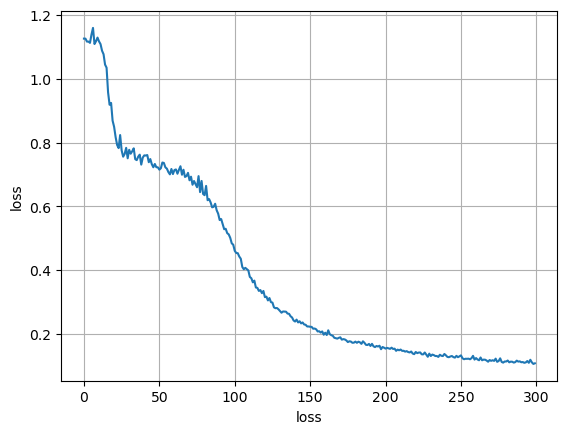

In [2]:
plt_x = range(len(loss_list))
plt.plot(plt_x, loss_list)
plt.xlabel('loss')
plt.ylabel('loss')
plt.grid()
plt.show()

# Chapter 2
## count base

goodbye 0.7071067691154799
i 0.7071067691154799
hello 0.7071067691154799
say 0.0
and 0.0
[[0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 1. 0. 1. 1. 0.]
 [0. 1. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 1. 0. 0.]
 [0. 1. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0.]]
[[0.    1.807 0.    0.    0.    0.    0.   ]
 [1.807 0.    0.807 0.    0.807 0.807 0.   ]
 [0.    0.807 0.    1.807 0.    0.    0.   ]
 [0.    0.    1.807 0.    1.807 0.    0.   ]
 [0.    0.807 0.    1.807 0.    0.    0.   ]
 [0.    0.807 0.    0.    0.    0.    2.807]
 [0.    0.    0.    0.    0.    2.807 0.   ]]
[-3.409e-01 -1.110e-16 -3.886e-16 -1.205e-01  0.000e+00  9.323e-01
  2.664e-16]


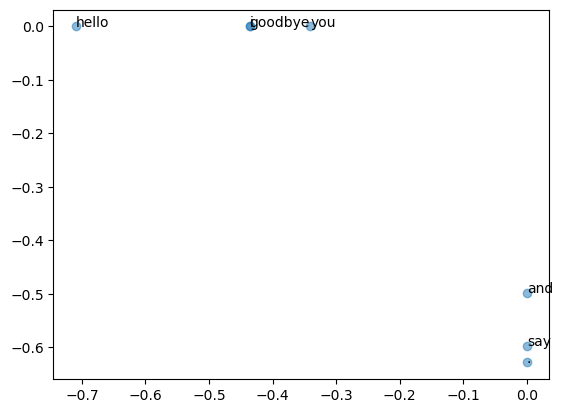

In [3]:
def preprocess(text):
    text = text.lower()
    text = text.replace('.', ' .')
    words = text.split(' ')
    word_to_id = {}
    id_to_word = {}
    for word in words:
        if word not in word_to_id:
            new_id = len(word_to_id)
            word_to_id[word] = new_id
            id_to_word[new_id] = word
    corpus = np.array([word_to_id[word] for word in words])

    return corpus, word_to_id, id_to_word


def create_co_matrix(corpus, vocab_size, window_size=1):
    M = np.zeros([vocab_size, vocab_size])
    for id, c in enumerate(corpus):
        for i in range(1, window_size+1):
            left_id = id-i
            right_id = id+i

            if left_id>=0:
                M[c][corpus[left_id]] += 1
            if right_id <len(corpus):
                M[c][corpus[right_id]] += 1
    return M

def cos_sim(a, b, eps = 1e-8):
    na =  a / (np.sqrt(np.sum(a**2))+eps)
    nb =  b / (np.sqrt(np.sum(b**2))+eps)
    return np.dot(na, nb)

def most_similar(query, word_to_id, id_to_word, word_matrix, top=5):
    query_id = word_to_id[query]
    cos_sims = []
    for id in id_to_word:
        #if query_id!=id:
        cos_sims.append(cos_sim(word_matrix[query_id], word_matrix[id]))
    cos_sims = np.array(cos_sims)
    cnt = 0
    for id in (-1*cos_sims).argsort():
        if id==query_id:continue
        print('%s %s'%(id_to_word[id], cos_sims[id]))
        cnt += 1
        if cnt>=top:return 

def ppmi(C, verbose=False, eps=1e-8):
    M = np.zeros_like(C, dtype=np.float32)
    N = np.sum(C)
    S = np.sum(C, axis = 0)
    total = C.shape[0]*C.shape[1]
    cnt = 0
    for i in range(C.shape[0]):
        for j in range(C.shape[1]):
            pmi = np.log2(C[i][j]*N/(S[i]*S[j])+eps)
            M[i][j] = max(0, pmi)
            if verbose:
                cnt+=1
                if cnt%(total//100+1)==0:
                    print('%.1f%% done' %(100*cnt/total))
    return M
text = "You say goodbye and I say hello."
corpus, word_to_id, id_to_word = preprocess(text)
co_matrix = create_co_matrix(corpus, len(set(corpus)))
most_similar('you', word_to_id, id_to_word, co_matrix)
np.set_printoptions(precision=3)
W = ppmi(co_matrix)
print(co_matrix)
print(W)
U, S, V = np.linalg.svd(W)
print(U[0])
for w, w_id in word_to_id.items():
    plt.annotate(w, (U[w_id, 0], U[w_id, 1]))

plt.scatter(U[:, 0], U[:, 1], alpha = 0.5)
plt.show()

In [4]:
### big corpus by SVD

In [4]:
from dataset import ptb
window_size = 2
wordvec_size = 100

corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)
print('counting  co-occurrence ...')
C = create_co_matrix(corpus, vocab_size, window_size)
print('calculating PPMI ...')
W = ppmi(C, verbose=True)

print('calculating SVD ...')
try:
    # truncated SVD (fast!)
    from sklearn.utils.extmath import randomized_svd
    U, S, V = randomized_svd(W, n_components=wordvec_size, n_iter=5,
                             random_state=None)
except ImportError:
    # SVD (slow)
    U, S, V = np.linalg.svd(W)

word_vecs = U[:, :wordvec_size]

querys = ['you', 'year', 'car', 'toyota']
for query in querys:
    most_similar(query, word_to_id, id_to_word, word_vecs, top=5)


counting  co-occurrence ...
calculating PPMI ...
1.0% done
2.0% done
3.0% done
4.0% done
5.0% done
6.0% done
7.0% done
8.0% done
9.0% done
10.0% done
11.0% done
12.0% done
13.0% done
14.0% done
15.0% done
16.0% done
17.0% done
18.0% done
19.0% done
20.0% done
21.0% done
22.0% done
23.0% done
24.0% done
25.0% done
26.0% done
27.0% done
28.0% done
29.0% done
30.0% done
31.0% done
32.0% done
33.0% done
34.0% done
35.0% done
36.0% done
37.0% done
38.0% done
39.0% done
40.0% done
41.0% done
42.0% done
43.0% done
44.0% done
45.0% done
46.0% done
47.0% done
48.0% done
49.0% done
50.0% done
51.0% done
52.0% done
53.0% done
54.0% done
55.0% done
56.0% done
57.0% done
58.0% done
59.0% done
60.0% done
61.0% done
62.0% done
63.0% done
64.0% done
65.0% done
66.0% done
67.0% done
68.0% done
69.0% done
70.0% done
71.0% done
72.0% done
73.0% done
74.0% done
75.0% done
76.0% done
77.0% done
78.0% done
79.0% done
80.0% done
81.0% done
82.0% done
83.0% done
84.0% done
85.0% done
86.0% done
87.0% done
88.

# Chapter 3
## word2veec introduction

### context util

In [5]:
def create_contexts_target(corpus, window_size=1):
    target = corpus[window_size:-window_size]
    contexts = []
    for idx in range(window_size, len(corpus)-window_size):
        cs = []
        for t in range(-window_size, window_size+1):
            if t==0:
                continue
            cs.append(corpus[idx+t])
        contexts.append(cs)
    return np.array(contexts), np.array(target)

def convert_one_hot(vec, vocab_size):
    N = vec.shape[0]
    if vec.ndim==1:
        one_hot = np.zeros((N, vocab_size), dtype=np.int32)
        for idx, val in enumerate(vec):
            one_hot[idx, val] = 1
    elif vec.ndim==2:
        C = vec.shape[1]
        one_hot = np.zeros((N, C, vocab_size), dtype=np.int32)
        for idx1, context in enumerate(vec):
            for idx2, val in enumerate(context):
                one_hot[idx1, idx2, val] = 1
    return one_hot

### Simple Model Inpelementation

In [6]:
class SimpleCBOW:
    def __init__(self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size
        W_in = 0.01*np.random.randn(V, H).astype('f')
        W_out = 0.01*np.random.randn(H, V).astype('f')

        self.layer1 = MatMul(W_in)
        self.layer2 = MatMul(W_in)
        self.out_layer = MatMul(W_out)
        self.loss_layer = SoftMaxWithLoss()

        self.layers = [
            self.layer1,
            self.layer2,
            self.out_layer,
        ]
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

        self.word_ves = W_in

    def forward(self, contexts, target):
        h1 = self.layer1.forward(contexts[:,0])
        h2 = self.layer2.forward(contexts[:,1])
        h = (h1+h2)/2
        score = self.out_layer.forward(h)
        loss = self.loss_layer.forward(score, target)
        return loss

    def backward(self, dout=1):
        ds = self.loss_layer.backward(dout)
        do = self.out_layer.backward(ds)
        do *= 0.5
        self.layer1.backward(do)
        self.layer2.backward(do)
        return None

class SimpleSkipGram:
    def __init__(self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size
        W_in = 0.01*np.random.randn(V, H).astype('f')
        W_out = 0.01*np.random.randn(H, V).astype('f')

        self.in_layer = MatMul(W_in)
        self.out_layer = MatMul(W_out)
        self.loss_layer1 = SoftMaxWithLoss()
        self.loss_layer2 = SoftMaxWithLoss()

        self.layer = [
            self.in_layer,
            self.out_layer
        ]
        self.params, self.grads = [], []
        for l in self.layer:
            self.params += l.params
            self.grads += l.grads
        self.word_vec = W_in

    def forward(self, contexts, target):
        h = self.in_layer.forward(target)
        s = self.out_layer.forward(h)
        l1 = self.loss_layer1.forward(s, contexts[:, 0])
        l2 = self.loss_layer2.forward(s, contexts[:, 1])
        loss = l1 + l2
        return loss

    def backward(self, dout=1):
        dl1 = self.loss_layer1.backward(dout)
        dl2 = self.loss_layer2.backward(dout)
        ds = dl1 + dl2
        dh = self.out_layer.backward(ds)
        self.in_layer.backward(dh)
        return None

In [7]:
text = "You say goodbye and I say hello."
corpus, word_to_id, id_to_word = preprocess(text)
contexts, target = create_contexts_target(corpus)
vocab_size = len(word_to_id)
contexts = convert_one_hot(contexts, vocab_size)
target = convert_one_hot(target, vocab_size)

### Simple CBOW Train

| epoch 1 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 2 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 3 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 4 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 5 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 6 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 7 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 8 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 9 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 10 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 11 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 12 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 13 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 14 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 15 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 16 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 17 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 18 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 19 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 20 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 21 |  iter 1 / 2 | ti

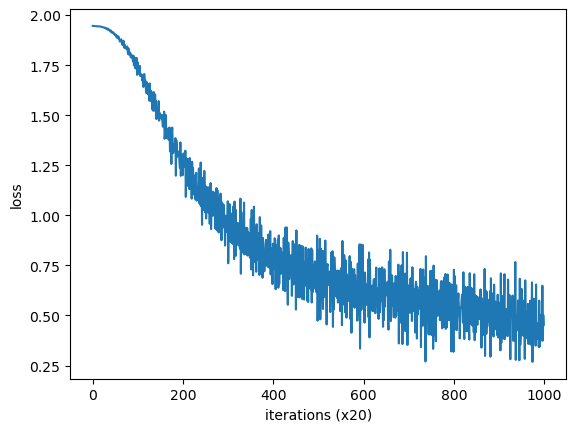

In [8]:
from common.trainer import Trainer
from common.optimizer import Adam

window_size = 1
hidden_size = 5
batch_size = 3
max_epoch = 1000
model = SimpleCBOW(vocab_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)
trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

### Simple SkipGram Train

| epoch 1 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 2 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 3 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 4 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 5 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 6 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 7 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 8 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 9 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 10 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 11 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 12 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 13 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 14 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 15 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 16 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 17 |  iter 1 / 2 | time 0[s] | loss 3.88
| epoch 18 |  iter 1 / 2 | time 0[s] | loss 3.88
| epoch 19 |  iter 1 / 2 | time 0[s] | loss 3.88
| epoch 20 |  iter 1 / 2 | time 0[s] | loss 3.88
| epoch 21 |  iter 1 / 2 | ti

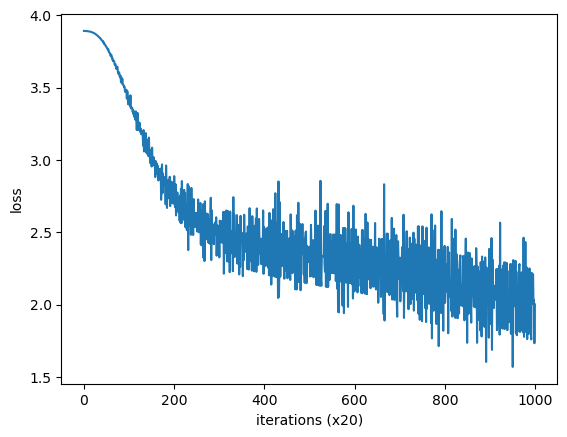

In [9]:
from common.trainer import Trainer
from common.optimizer import Adam

window_size = 1
hidden_size = 5
batch_size = 3
max_epoch = 1000
model = SimpleSkipGram(vocab_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)
trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

# Chapter 4
## word2vec optimization

In [7]:
class Embedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = np.zeros_like(W)
        self.idx = None

    def forward(self, idx):
        W, = self.params
        self.idx = idx
        out = W[idx]
        return out

    def backward(self, dout):
        dW, = self.grads
        dW[...] = 0
        for idx, w in enumerate(self.dix):
            dW[w] += dout[idx]
        return None

class EmbeddingDot:
    def __init__(self, W):
        self.embed = Embedding(W)
        self.params = self.embed.params
        self.grads = self.embed.grads
        self.cache = None

    def forward(self, h, idx):
        target_W = self.embed.forward(idx)
        out = np.sum(target_W*h, axis=1)
        self.cache = (h, target_W)
        return out

    def backward(self, dout=1):
        h, target_W = self.cache
        dout = dout.reshape(dout.shape[0], 1)
        dtarget_W = dout*h
        self.embed.backward(dtarget_W)
        dh = dout*target_W
        return dh

from ch04.negative_sampling_layer import UnigramSampler
class NegativeSamplingLoss:
    def __init__(self, W, corpus, power=0.7, sample_size=5):
        self.sample_size = sample_size
        self.sampler = UnigramSampler(corpus, power, sample_size)
        self.loss_layer = [SigmoidWithLoss() for _ in range(sample_size+1)]
        self.embed_dot_layers = [EmbeddingDot() for _ in range(sample_size+1)]
        self.params, self.grads = [], []
        for layer in self.embed_dot_layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, h, target):
        batch_size = target.shape[0]
        negative_sample =self.sampler.get_negative_sample(target)
        score = self.embed_dot_layers[0].forward(h, target)
        correct_label = np.ones(batch_size, dtype=int32)
        loss = self.loss_layer[0].forward(score, correct_label)

        negative_label = np.zeros(batch_size, dtype=int32)
        for i in range(sample_size):
            negative_target = negative_sample[:, i]
            score = self.embed_dot_layers[1+i].forward(h, negative_target)
            loss += self.loss_layer[i+1].forward(score, negative_label)

        return loss

    def backward(self, dout=1):
        dh = 0
        for l0, l1 in zip(self.embed_dot_layers, self.loss_layer):
            dscore = l1.backward(dout)
            dh += l0.backward(dscore)

        return dh

class CBOW:
    def __init__(self, vocab_size, hidden_size, window_size, corpus):
        V, H = vocab_size, hidden_size
        W_in = 0.01*np.random.randn(V, H).astype('f')
        W_out = 0.01*np.random.randn(H, V).astype('f')
        self.in_layers = []
        for i in range(2*window_size):
            layer = EmbeddingDot(W_in)
            self.in_layers.append(layer)
        self.ns_loss = NegativeSamplingLoss(W_out, corpus)
        self.params, self.grads = [], []
        layers = self.in_layers + [self.ns_loss]
        for l in layers:
            self.params += l.params
            self.grads += l.grads
        self.word_vec = W_in

    def forward(self, contexts, target):
        h = 0
        for i, layer in enumerate(self.in_layers):
            h += layer.forward(contexts[:, i])
        h *= 1/len(self.in_layers)
        loss = self.ns_layer.forward(h, target)
        return loss

    def backward(self, dout=1):
        dout = self.ns_layer.backward(dout)
        dout *= 1/len(self.in_layers)
        for layer in self.in_layers:
            layer.backward(dout)
        return None

# Chapter 5
## Reccurent Nueral Network

In [12]:
class RNN:
    def __init__(self, x, Wh, b):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.cache = None

    def forward(self, x, h_prev):
        Wx, Wh, b = self.params
        t = np.dot(h_prev*Wh) + np.dot(x+W_x) + b
        h_next = np.tanh(t)
        self.cache = (x, h_prev, h_next)
        return h_next
    
    def backward(self, dh_next):
        Wx, Wh, b = self.params
        x, h_prev, h_next = self.cache
        dt = dh_next*(1-h_next**2)
        db = np.sum(dt, azis=0)
        dWh = np.dot(h_prev.T, dt)
        dh_prev = np.dot(dt, Wh.T)
        dWx = np.dot(x.T, dt)
        dx = np.dot(dt, Wx.T)

        self.grads[0][...] = dWx
        self.grads[1][...] = dWh
        self.grads[2][...] = db

class TimeRNN:
    def __init__(self, Wx, Wh, b, stateful = False):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.cache = None
        self.layers = None
        self.h, self.dh = None, None
        self.stateful = stateful

    def set_state(self, h):
        self.h = h

    def reset_state(self):
        self.h = None

    def forward(self, xs):
        Wx, Wh, b = self.params
        N, T, D = xs.shape
        D, H = Wx.shape
        self.layers = []
        hs = np.empty((N, T, H), dtype = 'f')
        if not self.stateful or self.h is None:
            self.h = np.zeros((N, H), dtype='f')
        for i in range(T):
            layer = TimeRNN(Wx, Wh, b)
            self.layers.append(layer)
        return hs

    def backward(self, dhs):
        Wx, Wh, b = self.params
        N, T, H = dhs.shape
        dxs = np.empty((N, T, D), dtype='f')
        dh = 0
        grads = [0, 0, 0]
        for t in reversed(range(T)):
            layer = self.layer[t]
            dx, dh = layer.backward(dhs[:, t, :]+dh)
            dxs[:, t, :] = dx
            for i, grad in enumerate(layer.grads):
                grads[i] += grad
        for i, grad in enumerate(grads):
            self.grads[i][...] = grad
        self.dh = dg
        return dxs

class TimeEmbedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.layers = None
        self.W = W

    def forward(self, xs):
        N, T = xs.shape
        V, D = self.shape
        out = np.empty((N, T, D), dtype='f')
        self.layers = []
        for t in range(T):
            layer = Embedding(self.W)
            out[:, t, :] = layer.forward(xs[:, t])
            self.layers.append(layer)
        return out

    def backward(self, dout):
        N, T, D = dout.shape
        grad = 0
        for t in range(T):
            layer = self.layers[t]
            layer.backward(dout[:, t, :])
            grad += layer.grads[0]

        self.grads[0][...] = grad
        return None

class TimeAffine:
    def __init__(self, W, b):
        self.params = [W, b]
        self.grads = [np.zeros_like(W), np.zeros_like(b)]
        self.x = None

    def forward(self, xs):
        N, T, D = xs.shape
        W, b = self.params
        rx = xs.reshape(N*T, -1)
        out = np.dot(rx, W)+b
        self.x = xs
        return out.reshape((N, T, -1))

    def backward(self, dout):
        x = self.x
        N, T, D = x.shape
        W, b = self.params

        dout = dout.reshape(N*T, -1)
        rx = x.reshape(N*T, -1)
        db = np.sum(dout, axis=0)
        dW = np.dot(rx.T, dout)
        dx = np.dot(dout, W.T)
        dx = dx.reshape(*x.shape)
        self.grads[0][...] = dW
        self.grads[1][...] = db
        return dx

class TimeSoftmaxWithLoss:
    def __init__(self):
        self.params, self.grads = [], []
        self.cache = None
        self.ignore_label = -1

    def forward(self, xs, ts):
        N, T, V = xs.shape

        if ts.ndim == 3:  # 教師ラベルがone-hotベクトルの場合
            ts = ts.argmax(axis=2)

        mask = (ts != self.ignore_label)

        # バッチ分と時系列分をまとめる（reshape）
        xs = xs.reshape(N * T, V)
        ts = ts.reshape(N * T)
        mask = mask.reshape(N * T)

        ys = softmax(xs)
        ls = np.log(ys[np.arange(N * T), ts])
        ls *= mask  # ignore_labelに該当するデータは損失を0にする
        loss = -np.sum(ls)
        loss /= mask.sum()

        self.cache = (ts, ys, mask, (N, T, V))
        return loss

    def backward(self, dout=1):
        ts, ys, mask, (N, T, V) = self.cache

        dx = ys
        dx[np.arange(N * T), ts] -= 1
        dx *= dout
        dx /= mask.sum()
        dx *= mask[:, np.newaxis]  # ignore_labelに該当するデータは勾配を0にする

        dx = dx.reshape((N, T, V))

        return dx

class SimpleRnnlm:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn
        embd_W = (rn(V, D)/100).astype('f')
        rnn_Wx = (rn(D, H)/np.sqrt(D)).astype('f')
        rnn_Wh = (rn(H, H)/np.sqrt(H)).astype('f')
        rnn_b = np.zeros(H).astype('f')
        affine_W = (rn(H, V)/np.sqrt(H)).astype('f')
        affine_b = zp.zeros(V).astype('f')
        self.layers = [
            TimeEmbedding(embd_W),
            TimeRNN(rnn_Wxm rnn_Wh, rnn_b, stateful=True),
            TimeAffine(affine_W, affine_b)
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        self.rnn_layer = self.layers[1]
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, xs, ts):
        for layer in self.layers:
            xs = layer.forward(xs)
        loss = self.loss_layer(xs, ts)
        return loss

    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def reset_state(self):
        self.rnn_layer.reset_state()